# Sudoku board threshold experiment

Ten notebook zaczyna eksperyment od zera i celowo zatrzymuje się na etapie:
- wczytanie obrazu,
- grayscale,
- odszumianie,
- `adaptive threshold`,
- lekkie czyszczenie binarki po thresholdzie.

Nie ma tutaj jeszcze:
- korekcji EXIF,
- wykrywania ramki planszy,
- perspektywy / warp,
- cięcia na siatkę 9x9.

To ma być mały, szybki poligon do porównywania wariantów preprocessingu na obrazkach z datasetu. Kolejne bloki będziemy dokładać dopiero wtedy, gdy ten etap będzie stabilny.

In [569]:
from pathlib import Path
import importlib
import sys

import cv2

DRAFT_DIR = Path("/home/wojtek/projects/sudoku/src/MachineLearning/draft")
if str(DRAFT_DIR) not in sys.path:
    sys.path.insert(0, str(DRAFT_DIR))

import sudoku_board_threshold_binary as threshold_binary
import sudoku_board_threshold_display as threshold_display
import sudoku_board_threshold_lines as threshold_lines
import sudoku_board_threshold_models as threshold_models
import sudoku_board_threshold_paths as threshold_paths
import sudoku_board_threshold_visualization as threshold_visualization
import sudoku_board_threshold_helpers as threshold_helpers

# Notebook jest często odpalany wielokrotnie w tym samym kernelu, więc sam
# reload helpera nie wystarcza. Przeładowujemy też moduły zależne, aby klasy
# i funkcje miały spójne definicje po zmianach w plikach .py.
threshold_models = importlib.reload(threshold_models)
threshold_paths = importlib.reload(threshold_paths)
threshold_display = importlib.reload(threshold_display)
threshold_binary = importlib.reload(threshold_binary)
threshold_lines = importlib.reload(threshold_lines)
threshold_visualization = importlib.reload(threshold_visualization)
threshold_helpers = importlib.reload(threshold_helpers)

ExperimentConfig = threshold_helpers.ExperimentConfig
REPO_ROOT = threshold_helpers.REPO_ROOT
DRAFT_DIR = threshold_helpers.DRAFT_DIR
resolve_active_image_path = threshold_helpers.resolve_active_image_path
path_for_display = threshold_helpers.path_for_display
load_image_bgr = threshold_helpers.load_image_bgr
resize_for_display = threshold_helpers.resize_for_display
plot_named_images = threshold_helpers.plot_named_images
build_denoise_variants = threshold_helpers.build_denoise_variants
build_threshold_variants = threshold_helpers.build_threshold_variants
build_cleanup_variants = threshold_helpers.build_cleanup_variants
build_repair_variants = threshold_helpers.build_repair_variants
detect_line_families = threshold_helpers.detect_line_families
build_line_family_overlays = threshold_helpers.build_line_family_overlays
build_bridged_line_family_overlays = threshold_helpers.build_bridged_line_family_overlays
build_merged_line_overlays = threshold_helpers.build_merged_line_overlays

In [570]:
CONFIG = ExperimentConfig(
    # Delikatna kalibracja HoughLinesP: trochę łatwiej łapiemy krótsze segmenty
    # i pozwalamy na minimalnie większą lukę między ich częściami.
    raw_hough_threshold=32,
    raw_min_line_length_ratio=0.07,
    raw_max_line_gap_ratio=0.014,
)

print(f"Repo root: {REPO_ROOT}")
print(f"Draft dir:  {DRAFT_DIR}")
print(f"Dataset root (current): {CONFIG.dataset_root}")
print(f"Hough threshold: {CONFIG.raw_hough_threshold}")
print(f"Hough min line length ratio: {CONFIG.raw_min_line_length_ratio}")
print(f"Hough max line gap ratio: {CONFIG.raw_max_line_gap_ratio}")


Repo root: /home/wojtek/projects/sudoku
Draft dir:  /home/wojtek/projects/sudoku/src/MachineLearning/draft
Dataset root (current): /home/wojtek/projects/sudoku/data/raw/boards
Hough threshold: 32
Hough min line length ratio: 0.07
Hough max line gap ratio: 0.014


## 1. Wybór obrazka

Są dwa tryby pracy:
1. ręczne wpisanie ścieżki do konkretnego obrazka,
2. automatyczny wybór pliku z `CONFIG.dataset_root` po indeksie.

Najprostszy workflow:
1. wpisz ścieżkę w komórce poniżej, jeśli chcesz pracować na jednym konkretnym obrazie,
2. jeśli pole zostanie puste, notebook użyje `CONFIG.dataset_root` i `CONFIG.selected_dataset_index`,
3. uruchom dalsze komórki.

Domyślnie **nie** stosujemy żadnej automatycznej korekcji orientacji. Chcemy zobaczyć obraz dokładnie takim, jaki trafia do pipeline'u.

In [571]:
IMAGE_PATH_INPUT = "/home/wojtek/projects/sudoku/examples/uploads/image1067.jpg"
# Przykład:
# IMAGE_PATH_INPUT = "/home/wojtek/projects/sudoku/data/raw/boards/przyklad/board_01.jpg"
# IMAGE_PATH_INPUT = "data/raw/boards/przyklad/board_01.jpg"

if IMAGE_PATH_INPUT.strip():
    typed_image_path = Path(IMAGE_PATH_INPUT).expanduser()
    if not typed_image_path.is_absolute():
        typed_image_path = (REPO_ROOT / typed_image_path).resolve()

    CONFIG.image_path = typed_image_path
    print(f"Manual image path enabled: {CONFIG.image_path}")
else:
    CONFIG.image_path = None
    print("Manual image path is empty. Notebook will use dataset_root + selected_dataset_index.")

Manual image path enabled: /home/wojtek/projects/sudoku/examples/uploads/image1067.jpg


In [572]:
ACTIVE_IMAGE_PATH, DATASET_IMAGES = resolve_active_image_path(CONFIG)

print(f"Found {len(DATASET_IMAGES)} image(s) under dataset root.")
preview_paths = DATASET_IMAGES[: CONFIG.preview_limit]
for index, path in enumerate(preview_paths):
    marker = "<-- selected" if path == ACTIVE_IMAGE_PATH else ""
    print(f"[{index:02d}] {path_for_display(path, CONFIG.dataset_root)} {marker}")

if len(DATASET_IMAGES) > CONFIG.preview_limit:
    print(f"... and {len(DATASET_IMAGES) - CONFIG.preview_limit} more")

print()
print(f"Active image: {ACTIVE_IMAGE_PATH}")

Found 559 image(s) under dataset root.
[00] mixed/image1005.jpg 
[01] mixed/image1009.jpg 
[02] mixed/image1019.jpg 
[03] mixed/image1024.jpg 
[04] mixed/image1041.jpg 
[05] mixed/image1072.jpg 
[06] mixed/image1073.jpg 
[07] mixed/image1080.jpg 
[08] mixed/image1088.jpg 
[09] mixed/image114.jpg 
[10] mixed/image117.jpg 
[11] mixed/image120.jpg 
[12] mixed/image126.jpg 
[13] mixed/image140.jpg 
[14] mixed/image148.jpg 
[15] mixed/image153.jpg 
[16] mixed/image166.jpg 
[17] mixed/image175.jpg 
[18] mixed/image176.jpg 
[19] mixed/image179.jpg 
... and 539 more

Active image: /home/wojtek/projects/sudoku/examples/uploads/image1067.jpg


In [573]:
source_bgr = load_image_bgr(ACTIVE_IMAGE_PATH)
display_bgr = resize_for_display(source_bgr, CONFIG.max_display_size)
gray_image = cv2.cvtColor(display_bgr, cv2.COLOR_BGR2GRAY)

print(f"Original shape: {source_bgr.shape}")
print(f"Display shape:  {display_bgr.shape}")


Original shape: (1182, 960, 3)
Display shape:  (1182, 960, 3)


## 2. Odszumianie

Najpierw porównujemy kilka prostych wariantów odszumiania. Na tym etapie chodzi tylko o szybkie sprawdzenie, który wariant najlepiej zachowuje linie siatki i nie rozmywa ich zbyt agresywnie.

In [574]:
denoise_variants = build_denoise_variants(gray_image, CONFIG)
selected_denoise_image = denoise_variants[CONFIG.selected_denoise_variant]

print("Available denoise variants:")
for variant_name in denoise_variants:
    marker = "<-- selected" if variant_name == CONFIG.selected_denoise_variant else ""
    print(f"- {variant_name} {marker}")


Available denoise variants:
- raw_gray 
- gaussian_5 
- median_5 <-- selected
- bilateral 
- nl_means 


## 3. Adaptive threshold

Dalej porównujemy kilka kombinacji `blockSize` i `C` na jednym, wybranym wariancie odszumiania.

Po wybraniu najlepszego progu robimy jeszcze lekki `binary cleanup`, bo właśnie ten etap dawał lepszy efekt w `sudoku_board_frame_debug_split.ipynb` niż sama zmiana filtra odszumiającego na grayscale.

In [575]:
threshold_variants = build_threshold_variants(selected_denoise_image, CONFIG)

if CONFIG.selected_threshold_name is None:
    SELECTED_THRESHOLD_NAME = next(iter(threshold_variants))
else:
    SELECTED_THRESHOLD_NAME = CONFIG.selected_threshold_name

selected_binary = threshold_variants[SELECTED_THRESHOLD_NAME]

print(f"Adaptive method: {CONFIG.adaptive_method_name}")
print(f"Selected denoise variant: {CONFIG.selected_denoise_variant}")
print()
print("Available threshold variants:")
for variant_name in threshold_variants:
    marker = "<-- selected" if variant_name == SELECTED_THRESHOLD_NAME else ""
    print(f"- {variant_name} {marker}")


Adaptive method: gaussian
Selected denoise variant: median_5

Available threshold variants:
- gaussian_block11_c2 <-- selected
- gaussian_block11_c4 
- gaussian_block11_c6 
- gaussian_block15_c2 
- gaussian_block15_c4 
- gaussian_block15_c6 
- gaussian_block21_c2 
- gaussian_block21_c4 
- gaussian_block21_c6 
- gaussian_block31_c2 
- gaussian_block31_c4 
- gaussian_block31_c6 


In [576]:
min_component_area_px, cleanup_variants = build_cleanup_variants(selected_binary, CONFIG)

if CONFIG.selected_cleanup_variant is None:
    SELECTED_CLEANUP_NAME = next(iter(cleanup_variants))
else:
    SELECTED_CLEANUP_NAME = CONFIG.selected_cleanup_variant

selected_clean_binary = cleanup_variants[SELECTED_CLEANUP_NAME]
repair_variants = build_repair_variants(selected_clean_binary, CONFIG)

if CONFIG.selected_repair_variant is None:
    SELECTED_REPAIR_NAME = next(iter(repair_variants))
else:
    SELECTED_REPAIR_NAME = CONFIG.selected_repair_variant

selected_repaired_binary = repair_variants[SELECTED_REPAIR_NAME]

print()
print(f"Selected cleanup variant: {SELECTED_CLEANUP_NAME}")
print(f"Selected repair variant: {SELECTED_REPAIR_NAME}")
print(f"Connected components min area px: {min_component_area_px}")
print("Available cleanup variants:", ", ".join(cleanup_variants))
print("Available repair variants:", ", ".join(repair_variants))

print("Notebook continues with line-family visualization below.")
print("Next blocks should start from `selected_repaired_binary` and its detected line families.")


Selected cleanup variant: adaptive_plus_components_soft
Selected repair variant: directional_close
Connected components min area px: 74
Available cleanup variants: adaptive_only, adaptive_plus_components_soft, adaptive_plus_components
Available repair variants: cleanup_only, close_square_3, close_square_5, directional_close
Notebook continues with line-family visualization below.
Next blocks should start from `selected_repaired_binary` and its detected line families.


## 4. Naprawa linii, rodziny i scalanie

Ta sekcja nie pokazuje już wszystkich wariantów po kolei. Skupiamy się tylko na aktualnie wybranej ścieżce:
- `selected_binary`,
- `selected_cleanup`,
- `selected_repair`,
- końcowe rodziny `horizontal` i `vertical`,
- logiczne grupy segmentów w każdej rodzinie.

Segmenty łączą się tylko w obrębie tej samej rodziny. Jeśli A łączy się z B, a B z C, to na końcu traktujemy je jako jedną logiczną grupę wielu małych segmentów. Nie rysujemy sztucznej prostej między skrajnymi końcami. Zapisujemy za to:
- obwiednię grupy (`span`),
- realne pokrycie przez segmenty (`covered`),
- sumę długości surowych segmentów (`raw_len`),
- liczbę przeciętych linii z drugiej rodziny,
- liczbę punktów styczności.

Końcową selekcję robimy teraz iteracyjnie. Startujemy od pełnego zbioru logicznych linii po scalaniu i bridge repair, zostawiamy tylko te, które mają co najmniej `CONFIG.min_cross_family_touches_to_keep` punktów styczności, potem liczymy przecięcia jeszcze raz już na przefiltrowanym zbiorze i powtarzamy ten krok tak długo, aż nic więcej nie odpadnie. Dopiero taki stabilny zbiór pokazujemy jako finalną wersję. Na overlayach każda zachowana grupa ma własny kolor, żeby było od razu widać, czy segmenty zostały zgrupowane sensownie.


Line families from selected repair:
Raw Hough segments: 998
Raw min line length px: 67
Raw max line gap px: 13
Merge projection distance px: 11.5
Merge endpoint gap px: 24.0
Bridge projection tolerance px: 26.9
Bridge max gap px: 62.4
Bridge endpoint tolerance px: 26.9
Cross-family touch tolerance px: 19.2
Horizontal repaired bridges: 4
Vertical repaired bridges: 5
Min cross-family touches to keep: 9
Drop zero-touch lines after refresh: True
Expected kept lines: H=10, V=10
Horizontal family angle: 179.0 deg
Vertical family angle: 90.0 deg
Horizontal raw segments: 836
Vertical raw segments: 140
Horizontal logical groups before touch filter: 32
Vertical logical groups before touch filter: 27
Horizontal kept logical groups (after refresh): 11
Vertical kept logical groups (after refresh): 9

NOT YET: expected exactly 10 horizontal and 10 vertical logical lines.

Horizontal kept logical groups:
  H0: span=839.7px, covered=816.5px, segments=449, raw_len=75948.6px, touch_lines=1, touch_point

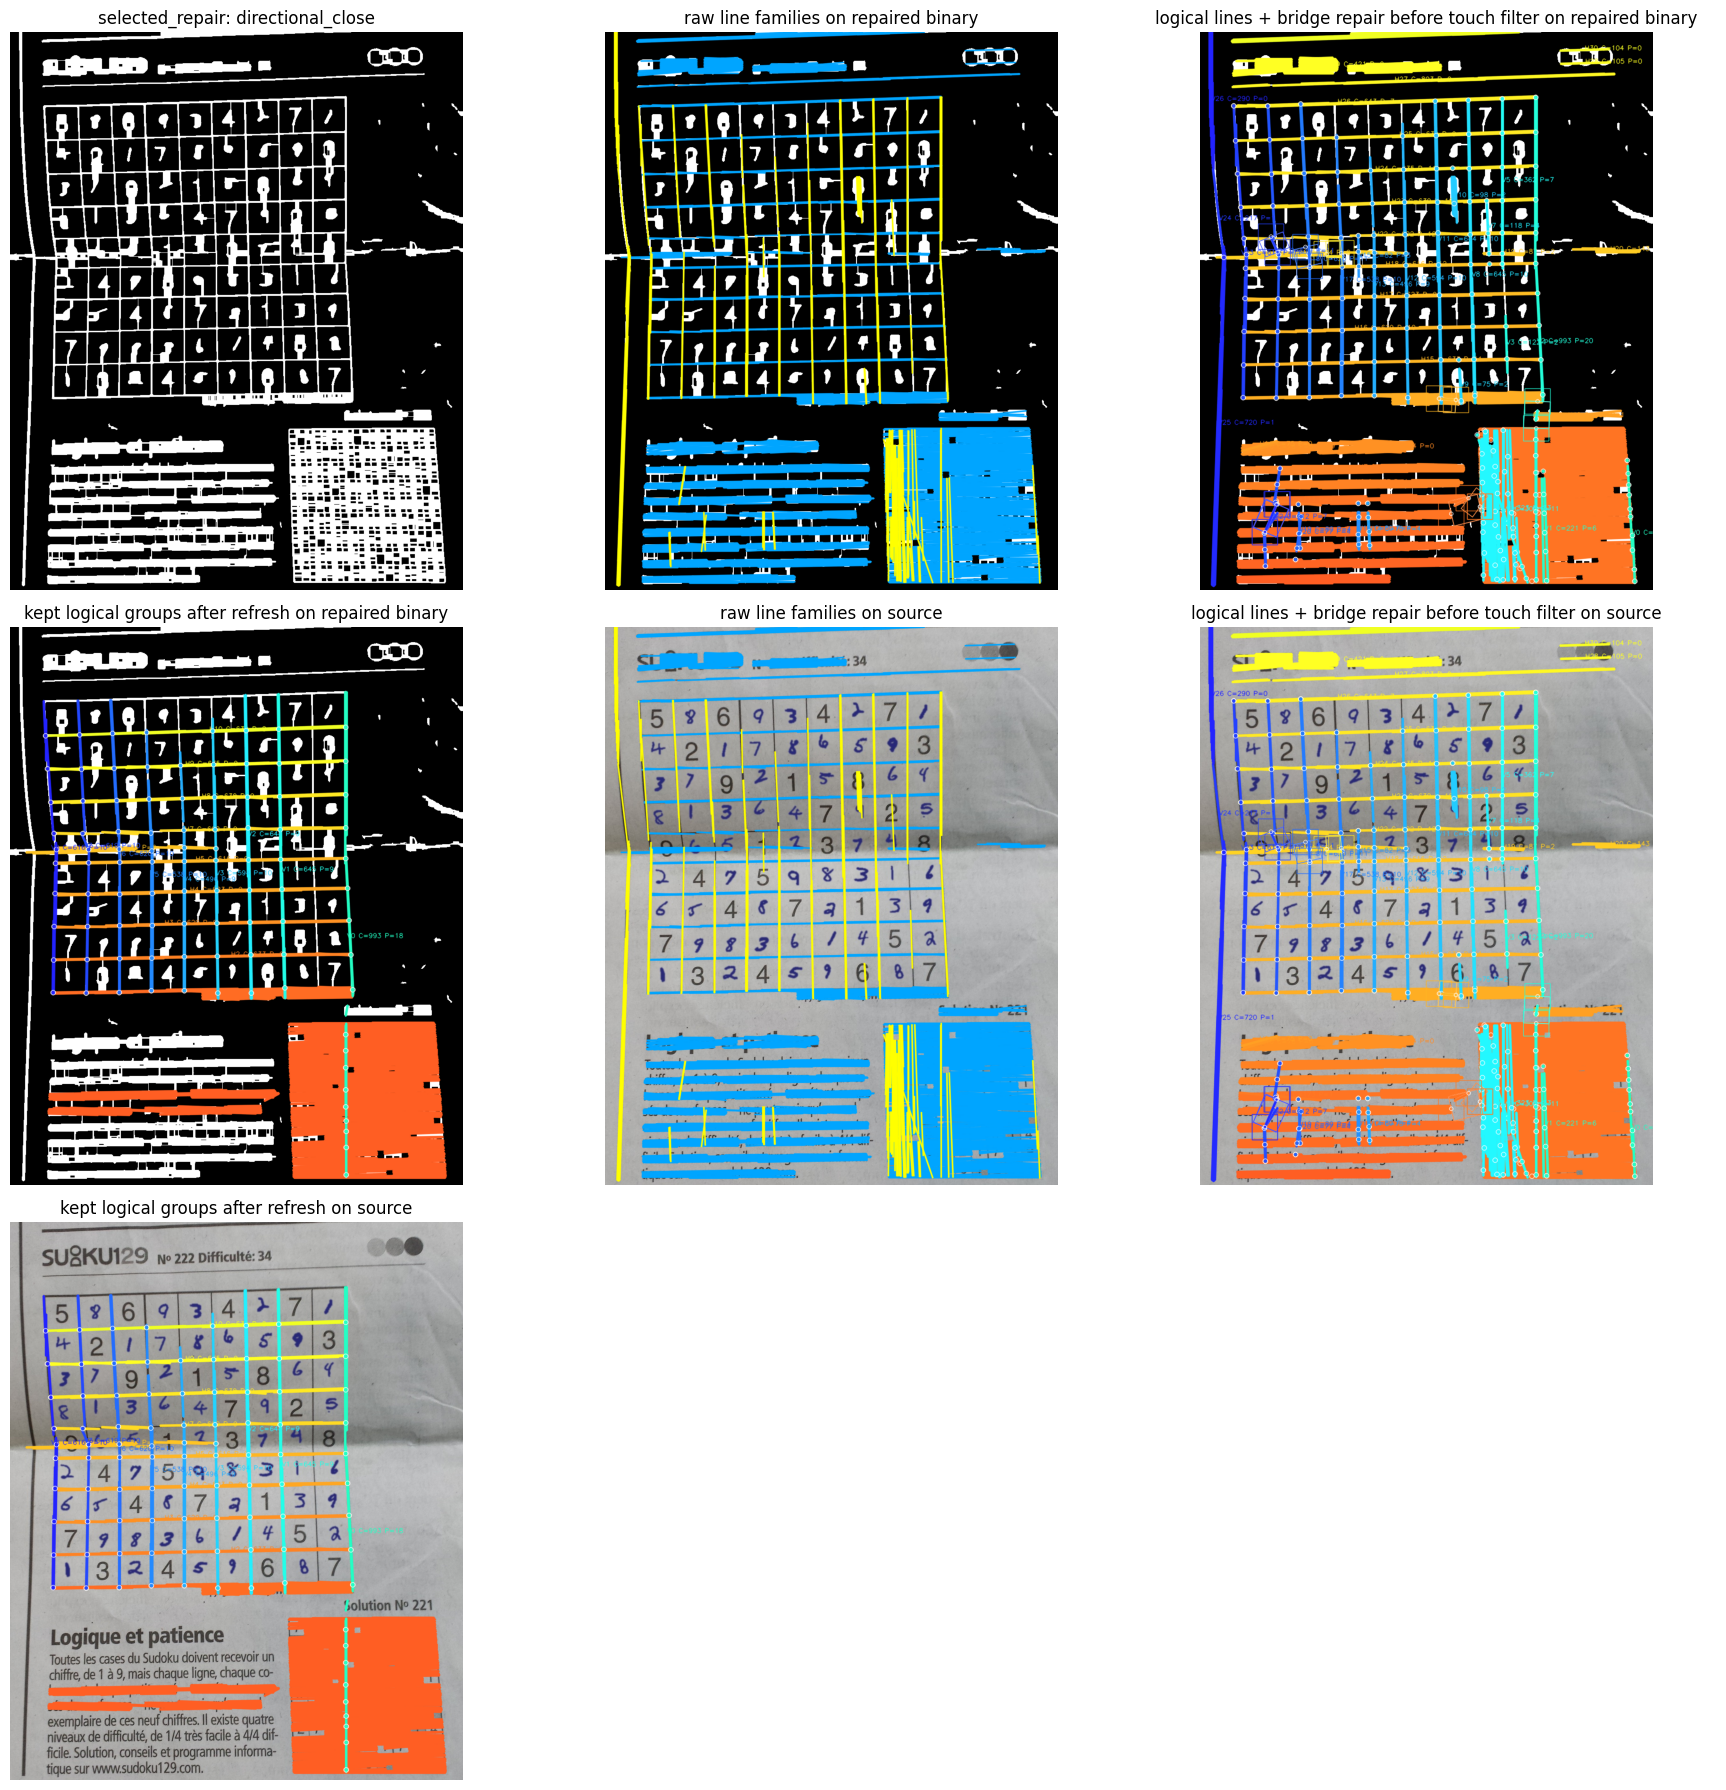

In [577]:
line_family_result = detect_line_families(selected_repaired_binary, CONFIG)
binary_family_overlay, source_family_overlay = build_line_family_overlays(
    display_bgr,
    selected_repaired_binary,
    line_family_result,
    CONFIG,
)
binary_logical_overlay, source_logical_overlay = build_bridged_line_family_overlays(
    display_bgr,
    selected_repaired_binary,
    line_family_result,
    CONFIG,
)
binary_merged_overlay, source_merged_overlay = build_merged_line_overlays(
    display_bgr,
    selected_repaired_binary,
    line_family_result,
    CONFIG,
)

horizontal_pre_filter_count = len(line_family_result.horizontal_pre_filter_merged_lines)
vertical_pre_filter_count = len(line_family_result.vertical_pre_filter_merged_lines)
horizontal_kept_count = len(line_family_result.horizontal_merged_lines)
vertical_kept_count = len(line_family_result.vertical_merged_lines)
is_success = (
    horizontal_kept_count == CONFIG.expected_horizontal_line_count
    and vertical_kept_count == CONFIG.expected_vertical_line_count
)

print()
print("Line families from selected repair:")
print(f"Raw Hough segments: {line_family_result.raw_segment_count}")
print(f"Raw min line length px: {line_family_result.raw_min_line_length_px}")
print(f"Raw max line gap px: {line_family_result.raw_max_line_gap_px}")
print(f"Merge projection distance px: {line_family_result.merge_projection_distance_px:.1f}")
print(f"Merge endpoint gap px: {line_family_result.merge_endpoint_gap_px:.1f}")
print(f"Bridge projection tolerance px: {line_family_result.bridge_projection_tolerance_px:.1f}")
print(f"Bridge max gap px: {line_family_result.bridge_max_gap_px:.1f}")
print(f"Bridge endpoint tolerance px: {line_family_result.bridge_endpoint_tolerance_px:.1f}")
print(
    f"Cross-family touch tolerance px: {line_family_result.cross_family_touch_tolerance_px:.1f}"
)
print(f"Horizontal repaired bridges: {len(line_family_result.horizontal_bridges)}")
print(f"Vertical repaired bridges: {len(line_family_result.vertical_bridges)}")
print(
    f"Min cross-family touch points to keep per iteration: "
    f"{CONFIG.min_cross_family_touches_to_keep}"
)
print(
    f"Expected kept lines: H={CONFIG.expected_horizontal_line_count}, "
    f"V={CONFIG.expected_vertical_line_count}"
)
print(
    "Horizontal family angle:",
    "n/a" if line_family_result.horizontal_angle_degrees is None else f"{line_family_result.horizontal_angle_degrees:.1f} deg",
)
print(
    "Vertical family angle:",
    "n/a" if line_family_result.vertical_angle_degrees is None else f"{line_family_result.vertical_angle_degrees:.1f} deg",
)
print(f"Horizontal raw segments: {len(line_family_result.horizontal_segments)}")
print(f"Vertical raw segments: {len(line_family_result.vertical_segments)}")
print(f"Horizontal logical groups before touch filter: {horizontal_pre_filter_count}")
print(f"Vertical logical groups before touch filter: {vertical_pre_filter_count}")
print(f"Horizontal kept logical groups (after refresh): {horizontal_kept_count}")
print(f"Vertical kept logical groups (after refresh): {vertical_kept_count}")
print()
if is_success:
    print("SUCCESS: detected exactly 10 horizontal and 10 vertical logical lines.")
else:
    print(
        "NOT YET: expected exactly "
        f"{CONFIG.expected_horizontal_line_count} horizontal and "
        f"{CONFIG.expected_vertical_line_count} vertical logical lines."
    )
print()
print("Horizontal kept logical groups:")
for line_index, merged_line in enumerate(line_family_result.horizontal_merged_lines):
    print(
        f"  H{line_index}: span={merged_line.span_length:.1f}px, "
        f"covered={merged_line.covered_length:.1f}px, "
        f"segments={merged_line.segment_count}, "
        f"raw_len={merged_line.total_segment_length:.1f}px, "
        f"touch_lines={merged_line.touching_line_count}, "
        f"touch_points={merged_line.touching_point_count}, "
        f"vertical_ids={list(merged_line.touching_line_indices)}, "
        f"points={list(merged_line.touching_points)}"
    )
print()
print("Vertical kept logical groups:")
for line_index, merged_line in enumerate(line_family_result.vertical_merged_lines):
    print(
        f"  V{line_index}: span={merged_line.span_length:.1f}px, "
        f"covered={merged_line.covered_length:.1f}px, "
        f"segments={merged_line.segment_count}, "
        f"raw_len={merged_line.total_segment_length:.1f}px, "
        f"touch_lines={merged_line.touching_line_count}, "
        f"touch_points={merged_line.touching_point_count}, "
        f"horizontal_ids={list(merged_line.touching_line_indices)}, "
        f"points={list(merged_line.touching_points)}"
    )

plot_named_images(
    [
        (f"selected_repair: {SELECTED_REPAIR_NAME}", selected_repaired_binary, False),
        ("raw line families on repaired binary", binary_family_overlay, True),
        ("logical lines + bridge repair before touch filter on repaired binary", binary_logical_overlay, True),
        ("kept logical groups after refresh on repaired binary", binary_merged_overlay, True),
        ("raw line families on source", source_family_overlay, True),
        ("logical lines + bridge repair before touch filter on source", source_logical_overlay, True),
        ("kept logical groups after refresh on source", source_merged_overlay, True),
    ],
    columns=3,
    figure_scale=6,
)